In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints

import matplotlib.pyplot as plt

In [ ]:
V = 'V0*(tanh(phi/sqrt(6)))**2*(1 + A*(sech((phi - phi0)/sigma))**2)'
parameters = {'V0' : 1.420e-10, 'A' : 6.402075e-4, 'phi0' : 5.580000, 'sigma': 1.428997e-2}
potential = PotentialFunction.from_string(V, param_values=parameters) 

#Creando instancia de la clase Background. Resuelve automáticamente el sistema dada la condición inicial del inflatón
background = Background(potential, phi0 = 6.3) 
background.solver()

In [3]:
#Extrayendo datos de la clase background
vars = ['N', 'phi', 'dphidN', 'H', 'a', 'aH', 'eps_H', 'eta_H']
N, phi, dphidN, H, a, aH, eps_H, eta_H = [background.data(save=True)[i] for i in vars]


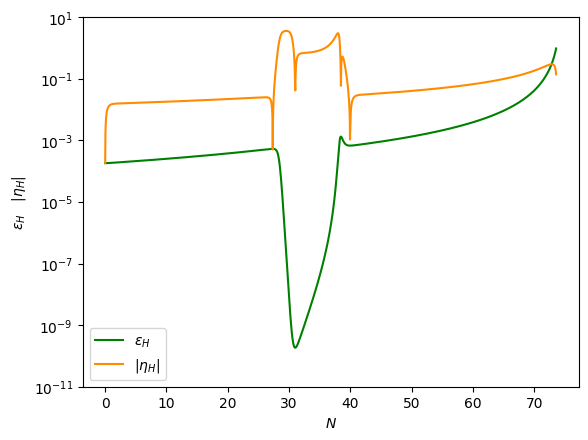

In [4]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')

plt.yscale('log')
plt.ylim(1e-11, 10)
plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 3)
#plt.title('Slow-roll parameters')



In [5]:
pert = Perturbations(potential, background, scale= 'PBH', N_CMB = 60)
sol = pert.Power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.0745741280993505e-09
Tensor to scalar ratio at pivot scale is 0.004463127086519975


In [6]:
PS = pert.Power_spectrum(save = True)

Computing P(k): 100%|██████████| 1000/1000 [01:24<00:00, 11.89it/s]


k_peak = 5.87\times 10^{+05} Mpc^-1
N_peak = 29.841440632088702
P_s(k_peak) = 0.04772119863238069
Figure saved as: Figures/spectrum_scalar.pdf


<Figure size 800x500 with 0 Axes>

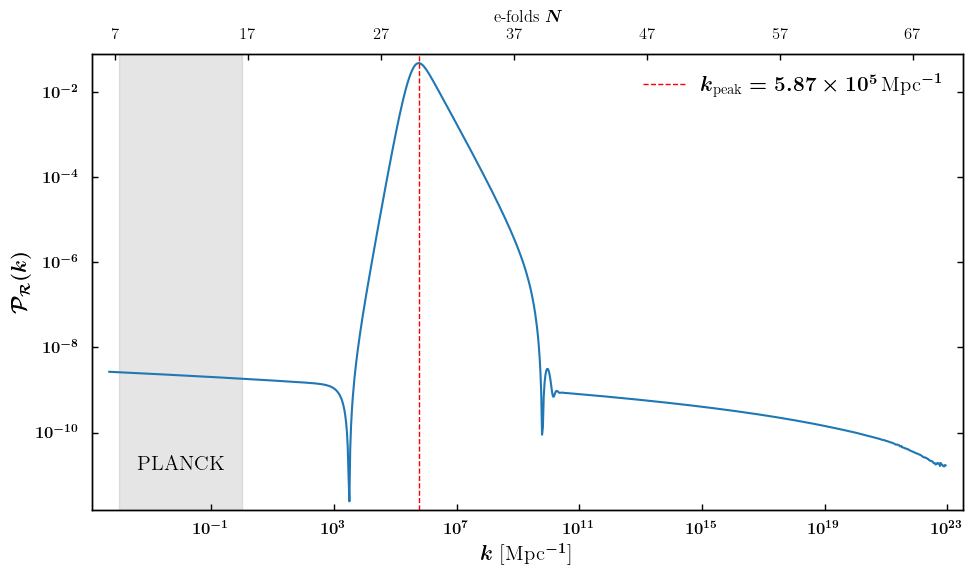

In [7]:
pert.Plot_spectrum(dpi = 100, spectrum = 'scalar', save = True)

In [8]:
print(pert.Spectral_tilts)

{'n_s': 0.9609653943743257, 'n_t': -0.0006999085085090474}


In [9]:
pbh = PBHAbundance(pert, delta_c= 0.4, gamma=0.2, gstar= 107.5)
mPBH, fPBH = pbh.fPBH(save=True)

fPBH_peak = 0.009840042762011201
MPBH_peak = 10.607933991970969 M⊙


In [10]:
constraints = PBHConstraints()
constraints.add_bound('Evap', 'Evaporation.txt')
constraints.add_bound('HSC',  'HSC.txt')
constraints.add_bound('CMB', 'CMB.txt')
constraints.add_bound('LIGO', 'LIGO.txt')
constraints.add_bound('Accretion', 'Accretion.txt')
constraints.add_bound('Dynamical', 'Dynamical.txt')
constraints.add_bound('EROS', 'EROS.txt')
constraints.add_bound('Kepler', 'Kepler.txt')
constraints.add_bound('Microlensing', 'Microlensing.txt')

  [OK] Cota cargada: Evap
  [OK] Cota cargada: HSC
  [ERROR] Fallo al leer CMB.txt: the number of columns changed from 2 to 1 at row 9; use `usecols` to select a subset and avoid this error
  [OK] Cota cargada: LIGO
  [OK] Cota cargada: Accretion
  [OK] Cota cargada: Dynamical
  [OK] Cota cargada: EROS
  [OK] Cota cargada: Kepler
  [OK] Cota cargada: Microlensing


fPBH_peak = 0.009840042762011201
MPBH_peak = 10.607933991970969 M⊙
fPBH_peak = 0.009840042762011201
MPBH_peak = 10.607933991970969 M⊙
Gráfico guardado en: Figures/constraints_check.png


<Figure size 2400x1500 with 0 Axes>

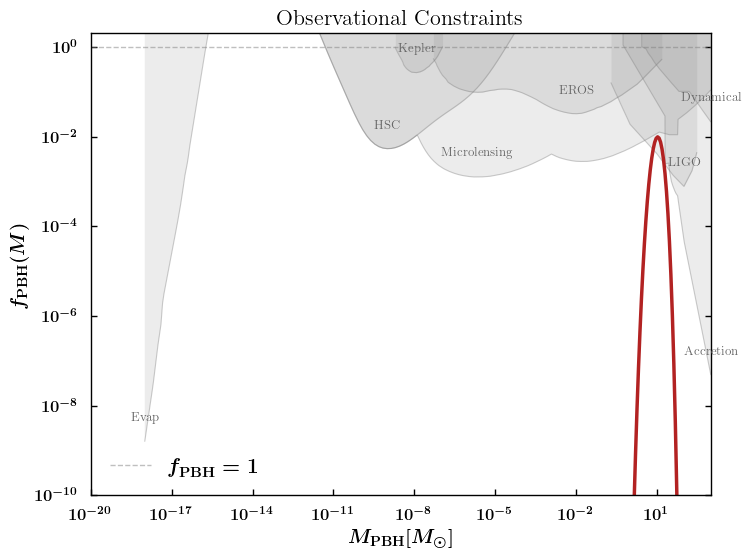

In [ ]:
constraints.plot_with_model(pbh)